# <a id='toc1_'></a>[Analyze Response for Different System Pole Locations](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [Analyze Response for Different System Pole Locations](#toc1_)    
  - [Nominal](#toc1_1_)    
  - [Move Left](#toc1_2_)    
  - [Move up](#toc1_3_)    
  - [Add Damping](#toc1_4_)    
  - [Move out](#toc1_5_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [1]:
%reload_ext autoreload
%autoreload 2 

In [2]:
# Course utilities (do not modify this cell)

from pathlib import Path
import sys

# repo_root/16_06_Class/notebooks → repo_root/16_06_Class
repo_root = Path.cwd().parents[0]
sys.path.insert(0, str(repo_root / "16_06_Class"))

import courseutils.basic_material as bm
import courseutils.control_materials as cm

print("Basic Material version:", bm.__version__)
print("Control Materials version:", cm.__version__)

bm.setup_environment()
cm.setup_environment()

Basic Material version: 16.06-0.3
Control Materials version: 16.06-0.2
Running Python: 3.12.12
Running SymPy: 1.13.3


In [3]:
import numpy as np
import matplotlib.pyplot as plt
colors = bm.get_colors()

import control as ct
import control.matlab as cmat

## <a id='toc1_1_'></a>[Nominal](#toc0_)

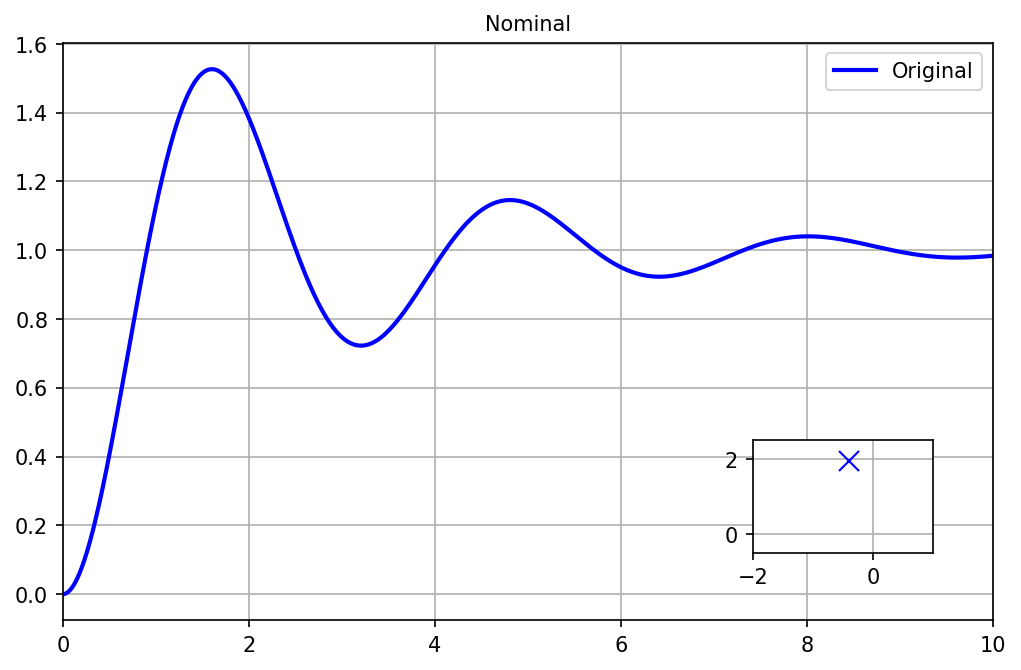

In [4]:
#key parameters
wn = 2
zeta = .2
wd = wn*np.sqrt(1-zeta**2)
sigma = zeta*wn
sigma_p = 1.5*sigma

# system
D = np.convolve((1,sigma),(1,sigma))+(0,0,wd**2)
G0 = ct.tf2ss(ct.tf(wn**2,D))

# response
yap,t = cmat.step(G0,np.linspace(0,10,1000))

fig, ax = plt.subplots(1, figsize=(8, 5), dpi=150, sharex=True, constrained_layout=False)
ax.plot(t,yap,'b-',label=r'Original')
plt.title('Nominal')
plt.legend()

left, bottom, width, height = [0.7, 0.2, 0.15, 0.15]
ax2 = fig.add_axes([left, bottom, width, height])
ax2.figure.set_facecolor('w')
ax2.plot(np.real(G0.poles()),np.imag(G0.poles()), 'x', ms=10, color='b')
ax2.set_xlim((-2,1))
ax2.set_ylim((-.5,2.5))
plt.show()

## <a id='toc1_2_'></a>[Move Left](#toc0_)

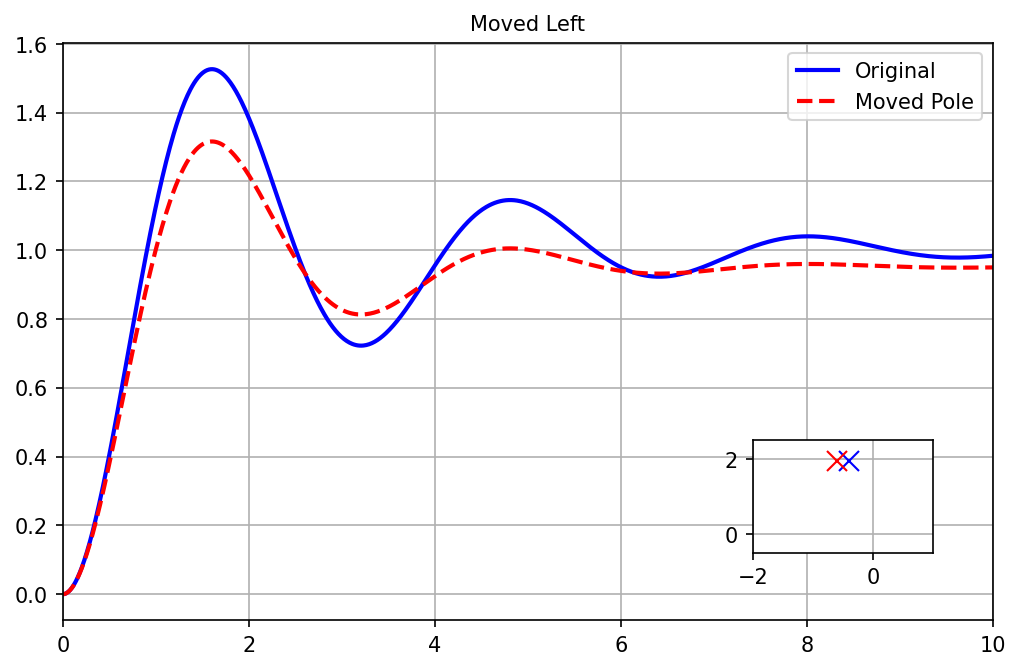

In [5]:
sigma_p = 1.5*sigma

D = np.convolve((1,sigma),(1,sigma))+(0,0,wd**2)
D_p = np.convolve((1,sigma_p),(1,sigma_p))+(0,0,wd**2)

G0 = ct.tf2ss(ct.tf(wn**2,D))
G1 = ct.tf2ss(ct.tf(wn**2,D_p))

yap,t = cmat.step(G0,T=t)
y1,t = cmat.step(G1,t)

fig, ax = plt.subplots(1, figsize=(8, 5), dpi=150, sharex=True, constrained_layout=False)

ax.plot(t,yap,'b-',label=r'Original')
ax.plot(t,y1,'r--',label=r'Moved Pole')
plt.title('Moved Left')
plt.legend()

left, bottom, width, height = [0.7, 0.2, 0.15, 0.15]
ax2 = fig.add_axes([left, bottom, width, height])
ax2.figure.set_facecolor('w')
ax2.plot(np.real(G0.poles()),np.imag(G0.poles()), 'x', ms=10, color='b')
ax2.plot(np.real(G1.poles()),np.imag(G1.poles()), 'x', ms=10, color='r')
ax2.set_xlim((-2,1))
ax2.set_ylim((-.5,2.5))

plt.show()

## <a id='toc1_3_'></a>[Move up](#toc0_)

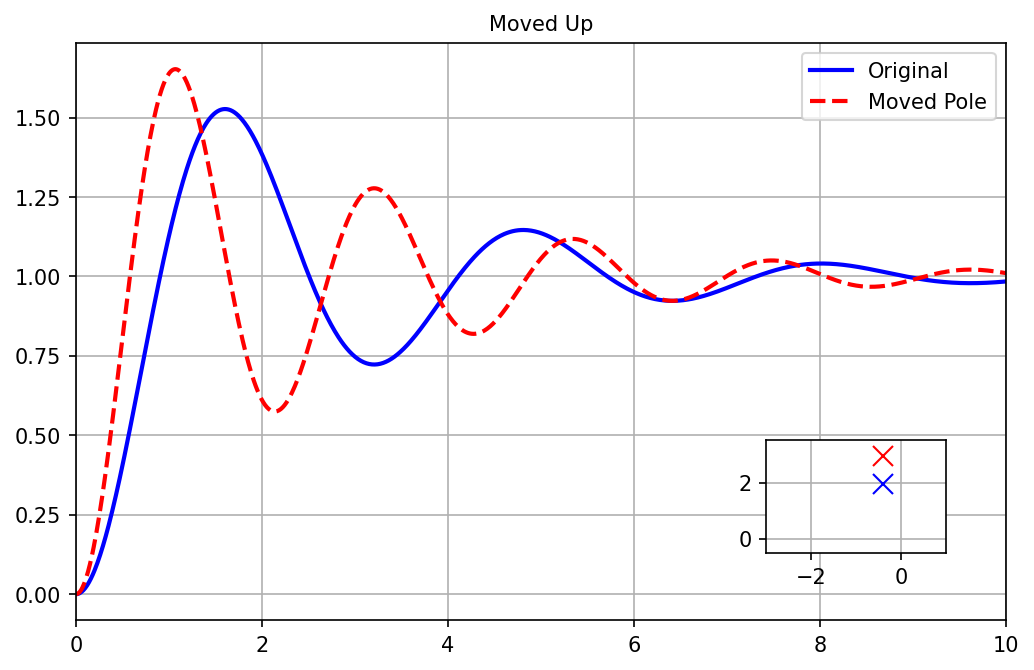

In [6]:
wd_p = 1.5*wd
zeta_p = sigma/np.sqrt(wd_p**2 + (sigma)**2)
wn_p = sigma/zeta_p

s = ct.tf('s')
# add faster with a zero
G0 = wn**2/((s+sigma)**2 + wd**2)
G1 = wn_p**2/((s+sigma)**2 + wd_p**2)

yap,t = cmat.step(G0,T=t)
y1,t = cmat.step(G1,T=t)

fig, ax = plt.subplots(1, figsize=(8, 5), dpi=150, sharex=True, constrained_layout=False)
ax.plot(t,yap,'b-',label=r'Original')
ax.plot(t,y1,'r--',label=r'Moved Pole')
plt.title('Moved Up')
plt.legend()

left, bottom, width, height = [0.7, 0.2, 0.15, 0.15]
ax2 = fig.add_axes([left, bottom, width, height])
ax2.figure.set_facecolor('w')
ax2.plot(np.real(G0.poles()),np.imag(G0.poles()), 'x', ms=10, color='b')
ax2.plot(np.real(G1.poles()),np.imag(G1.poles()), 'x', ms=10, color='r')
ax2.set_xlim((-3,1))
ax2.set_ylim((-.5,3.5))

plt.show()

## <a id='toc1_4_'></a>[Add Damping](#toc0_)


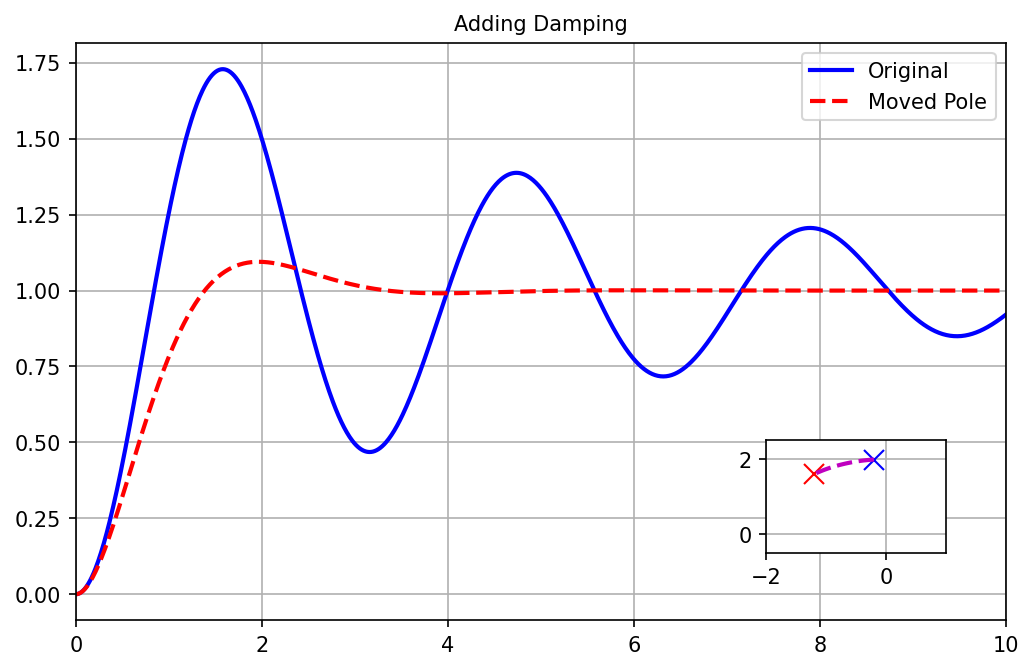

In [7]:
zeta = .1
zeta_p = .6

G0 = ct.tf2ss(ct.tf(wn**2,(1, 2*zeta*wn, wn**2)))
G1 = ct.tf2ss(ct.tf(wn**2,(1, 2*zeta_p*wn, wn**2)))

yap,t = cmat.step(G0,t)
y1,t = cmat.step(G1,t)

fig, ax = plt.subplots(1, figsize=(8, 5), dpi=150, sharex=True, constrained_layout=False)
ax.plot(t,yap,'b-',label=r'Original')
ax.plot(t,y1,'r--',label=r'Moved Pole')
plt.title('Adding Damping')
plt.legend()

left, bottom, width, height = [0.7, 0.2, 0.15, 0.15]
ax2 = fig.add_axes([left, bottom, width, height])
ax2.figure.set_facecolor('w')
ax2.plot(np.real(G0.poles()),np.imag(G0.poles()), 'x', ms=10, color='b')
ax2.plot(np.real(G1.poles()),np.imag(G1.poles()), 'x', ms=10, color='r')
ax2.set_xlim((-2,1))
ax2.set_ylim((-0.5,2.5))

theta0 = np.arccos(zeta)
theta1 = np.arccos(zeta_p)
theta = np.linspace(theta0,theta1,100)
ax2.plot(-wn*np.cos(theta),(wn*np.sin(theta)),'m--')

plt.show()

## <a id='toc1_5_'></a>[Move out](#toc0_)

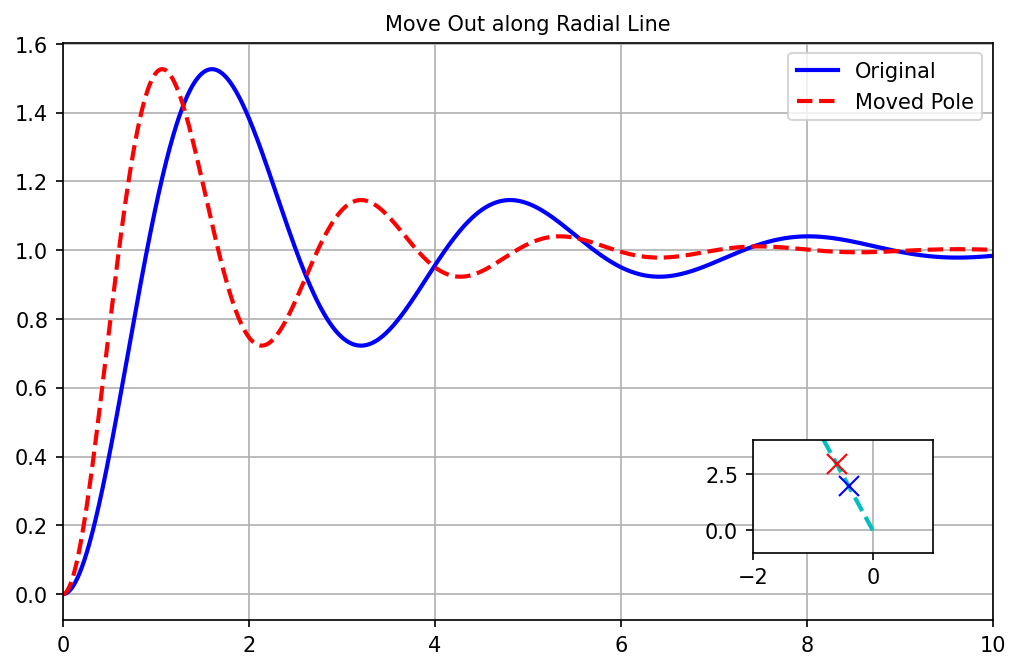

In [8]:
wn_p = wn*1.5
zeta = .2

G0 = ct.tf2ss(ct.tf(wn**2,(1, 2*zeta*wn, wn**2)))
G1 = ct.tf2ss(ct.tf(wn_p**2,(1, 2*zeta*wn_p, wn_p**2)))

yap,t = cmat.step(G0,t)
y1,t = cmat.step(G1,t)

fig, ax = plt.subplots(1, figsize=(8, 5), dpi=150, sharex=True, constrained_layout=False)
ax.plot(t,yap,'b-',label=r'Original')
ax.plot(t,y1,'r--',label=r'Moved Pole')
plt.title('Move Out along Radial Line')
plt.legend()

left, bottom, width, height = [0.7, 0.2, 0.15, 0.15]
ax2 = fig.add_axes([left, bottom, width, height])
ax2.figure.set_facecolor('w')
ax2.plot(np.real(G0.poles()),np.imag(G0.poles()), 'x', ms=10, color='b',zorder=10)
ax2.plot(np.real(G1.poles()),np.imag(G1.poles()), 'x', ms=10, color='r',zorder=10)
ax2.set_xlim((-2,1))
ax2.set_ylim((-1,4))

theta = np.arccos(zeta)
ax2.plot([0,-10*np.cos(theta)],[0,10*np.sin(theta)],'c--')

plt.show()